## Train  - Test Split

```python
"""Importing"""

from sklearn.model_selection import train_test_split

## X = input features related to the predicting feature
x = df.drop("Price",axis = 1)
y = df['Price']

X_train , X_test,y_train,y_test = train_test_split(
    x,y,test_size = .2,random_state = 42
)

# random_state = 42 is used here as a seed which will always create the same 
# train and test split no matter how many time we run it
```

In [78]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [79]:
raw = pd.read_csv('../Dataset/house_price.csv')
raw.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [80]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   str    
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   str    
 15  city           4600 non-null   str    
 16  statezip       4600 non-null   str    
 17  country        4600 non-null   str    
dtypes: float64(4), int6

In [81]:
cleaned = pd.DataFrame(columns = ['date'])

In [83]:
cleaned['date'] = pd.to_datetime(raw['date'])

In [84]:
cleaned['date']

0      2014-05-02
1      2014-05-02
2      2014-05-02
3      2014-05-02
4      2014-05-02
          ...    
4595   2014-07-09
4596   2014-07-09
4597   2014-07-09
4598   2014-07-10
4599   2014-07-10
Name: date, Length: 4600, dtype: datetime64[us]

In [85]:
raw.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='str')

In [195]:
columns = ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated']
cleaned[columns] = raw[columns]
cleaned.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,statezip_WA 98166,statezip_WA 98168,statezip_WA 98177,statezip_WA 98178,statezip_WA 98188,statezip_WA 98198,statezip_WA 98199,statezip_WA 98288,statezip_WA 98354,age
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,59
1,2014-05-02,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,93
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,48
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,51
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,38


In [194]:
raw['street'].unique()

<StringArray>
[    '18810 Densmore Ave N',          '709 W Blaine St',
 '26206-26214 143rd Ave SE',          '857 170th Pl NE',
        '9105 170th Ave NE',           '522 NE 88th St',
        '2616 174th Ave NE',        '23762 SE 253rd Pl',
  '46611-46625 SE 129th St',         '6811 55th Ave NE',
 ...
         '1028 SW 307th St',        '13602 SE 186th Pl',
       '3529 SW Webster St',          '37654 18th Pl S',
       '26306 127th Ave SE',           '501 N 143rd St',
         '14855 SE 10th Pl',         '759 Ilwaco Pl NE',
        '5148 S Creston St',        '18717 SE 258th St']
Length: 4525, dtype: str

In [89]:
street_freq = raw['street'].value_counts(normalize = True)
cleaned['street'] = raw['street']
cleaned['street_freq'] = raw['street'].map(street_freq)

In [94]:
cleaned.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,street_freq
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,0.000217
1,2014-05-02,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,0.000217
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,0.000217
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,0.000217
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,0.000217


In [91]:
raw['city'].unique()

<StringArray>
[          'Shoreline',             'Seattle',                'Kent',
            'Bellevue',             'Redmond',        'Maple Valley',
          'North Bend',    'Lake Forest Park',           'Sammamish',
              'Auburn',          'Des Moines',             'Bothell',
         'Federal Way',            'Kirkland',            'Issaquah',
         'Woodinville',       'Normandy Park',           'Fall City',
              'Renton',           'Carnation',          'Snoqualmie',
              'Duvall',              'Burien',           'Covington',
 'Inglewood-Finn Hill',             'Kenmore',           'Newcastle',
       'Mercer Island',       'Black Diamond',          'Ravensdale',
          'Clyde Hill',              'Algona',           'Skykomish',
             'Tukwila',              'Vashon',        'Yarrow Point',
              'SeaTac',              'Medina',            'Enumclaw',
     'Snoqualmie Pass',             'Pacific',  'Beaux Arts Village',
      

In [76]:
cleaned['street'] = cleaned['street'].str.lower()

In [57]:
cleaned['city'] = raw['city'].str.lower()

In [58]:
cleaned['city'].unique()

<StringArray>
[          'shoreline',             'seattle',                'kent',
            'bellevue',             'redmond',        'maple valley',
          'north bend',    'lake forest park',           'sammamish',
              'auburn',          'des moines',             'bothell',
         'federal way',            'kirkland',            'issaquah',
         'woodinville',       'normandy park',           'fall city',
              'renton',           'carnation',          'snoqualmie',
              'duvall',              'burien',           'covington',
 'inglewood-finn hill',             'kenmore',           'newcastle',
       'mercer island',       'black diamond',          'ravensdale',
          'clyde hill',              'algona',           'skykomish',
             'tukwila',              'vashon',        'yarrow point',
              'seatac',              'medina',            'enumclaw',
     'snoqualmie pass',             'pacific',  'beaux arts village',
      

In [92]:
cleaned

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,street_freq
0,2014-05-02,3.130000e+05,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,0.000217
1,2014-05-02,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,0.000217
2,2014-05-02,3.420000e+05,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,0.000217
3,2014-05-02,4.200000e+05,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,0.000217
4,2014-05-02,5.500000e+05,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,0.000217
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,2014-07-09,3.081667e+05,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,501 N 143rd St,0.000217
4596,2014-07-09,5.343333e+05,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,14855 SE 10th Pl,0.000217
4597,2014-07-09,4.169042e+05,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,0.000217
4598,2014-07-10,2.034000e+05,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,0.000217


In [95]:
from sklearn.preprocessing import OneHotEncoder

onehot = OneHotEncoder(sparse_output = False)
city_encoded = onehot.fit_transform(raw[['city']])
city_features = onehot.get_feature_names_out(['city'])
city_df = pd.DataFrame(city_encoded,columns = city_features)
temp = pd.concat([cleaned.reset_index(drop = True),city_df.reset_index(drop = True)],axis = 1)
chk1 = cleaned.copy()
cleaned = temp.copy()

In [96]:
chk1

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,street_freq
0,2014-05-02,3.130000e+05,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,0.000217
1,2014-05-02,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,0.000217
2,2014-05-02,3.420000e+05,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,0.000217
3,2014-05-02,4.200000e+05,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,0.000217
4,2014-05-02,5.500000e+05,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,0.000217
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,2014-07-09,3.081667e+05,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,501 N 143rd St,0.000217
4596,2014-07-09,5.343333e+05,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,14855 SE 10th Pl,0.000217
4597,2014-07-09,4.169042e+05,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,0.000217
4598,2014-07-10,2.034000e+05,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,0.000217


In [97]:
raw['statezip'].unique()

<StringArray>
['WA 98133', 'WA 98119', 'WA 98042', 'WA 98008', 'WA 98052', 'WA 98115',
 'WA 98038', 'WA 98045', 'WA 98155', 'WA 98105', 'WA 98074', 'WA 98106',
 'WA 98007', 'WA 98092', 'WA 98198', 'WA 98006', 'WA 98102', 'WA 98011',
 'WA 98125', 'WA 98003', 'WA 98136', 'WA 98033', 'WA 98029', 'WA 98117',
 'WA 98034', 'WA 98072', 'WA 98023', 'WA 98107', 'WA 98166', 'WA 98116',
 'WA 98024', 'WA 98055', 'WA 98077', 'WA 98027', 'WA 98059', 'WA 98075',
 'WA 98014', 'WA 98065', 'WA 98199', 'WA 98053', 'WA 98058', 'WA 98122',
 'WA 98103', 'WA 98112', 'WA 98005', 'WA 98118', 'WA 98177', 'WA 98004',
 'WA 98019', 'WA 98144', 'WA 98168', 'WA 98001', 'WA 98056', 'WA 98146',
 'WA 98028', 'WA 98148', 'WA 98057', 'WA 98040', 'WA 98010', 'WA 98051',
 'WA 98031', 'WA 98109', 'WA 98030', 'WA 98126', 'WA 98032', 'WA 98178',
 'WA 98288', 'WA 98108', 'WA 98070', 'WA 98188', 'WA 98002', 'WA 98039',
 'WA 98022', 'WA 98068', 'WA 98047', 'WA 98050', 'WA 98354']
Length: 77, dtype: str

In [142]:
cleaned['statezip'] = raw['statezip'] 
zip_encoded = onehot.fit_transform(raw[['statezip']])
zip_features = onehot.get_feature_names_out(['statezip'])
zip_df = pd.DataFrame(zip_encoded,columns = zip_features)
temp = pd.concat([cleaned.reset_index(drop = True),zip_df.reset_index(drop = True)],axis = 1)
chk2 = cleaned.copy()
cleaned = temp.copy()

In [143]:
temp['price']

0       3.130000e+05
1       2.384000e+06
2       3.420000e+05
3       4.200000e+05
4       5.500000e+05
            ...     
4595    3.081667e+05
4596    5.343333e+05
4597    4.169042e+05
4598    2.034000e+05
4599    2.206000e+05
Name: price, Length: 4600, dtype: float64

In [144]:
type(cleaned)

pandas.DataFrame

In [145]:
cleaned

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,statezip_WA 98155,statezip_WA 98166,statezip_WA 98168,statezip_WA 98177,statezip_WA 98178,statezip_WA 98188,statezip_WA 98198,statezip_WA 98199,statezip_WA 98288,statezip_WA 98354
0,2014-05-02,3.130000e+05,3.0,1.50,1340,7912,1.5,0,0,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2014-05-02,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2014-05-02,3.420000e+05,3.0,2.00,1930,11947,1.0,0,0,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2014-05-02,4.200000e+05,3.0,2.25,2000,8030,1.0,0,0,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2014-05-02,5.500000e+05,4.0,2.50,1940,10500,1.0,0,0,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,2014-07-09,3.081667e+05,3.0,1.75,1510,6360,1.0,0,0,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4596,2014-07-09,5.343333e+05,3.0,2.50,1460,7573,2.0,0,0,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4597,2014-07-09,4.169042e+05,3.0,2.50,3010,7014,2.0,0,0,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4598,2014-07-10,2.034000e+05,4.0,2.00,2090,6630,1.0,0,0,3,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [146]:
raw['country'].unique()

<StringArray>
['USA']
Length: 1, dtype: str

In [147]:
cleaned.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,statezip_WA 98155,statezip_WA 98166,statezip_WA 98168,statezip_WA 98177,statezip_WA 98178,statezip_WA 98188,statezip_WA 98198,statezip_WA 98199,statezip_WA 98288,statezip_WA 98354
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2014-05-02,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [67]:
## Data Cleaning Complete
cleaned.to_csv('../Dataset/ml_day2_house_pricing.csv',index = False)

## Cleaned Dataset

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [68]:
cleaned = pd.read_csv('../Dataset/ml_day2_house_pricing.csv')
raw = pd.read_csv('../Dataset/house_price.csv')

In [5]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   str    
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   str    
 15  city           4600 non-null   str    
 16  statezip       4600 non-null   str    
 17  country        4600 non-null   str    
dtypes: float64(4), int6

In [6]:
raw.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='str')

In [49]:
num_col = ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated','age','old']

In [8]:
cleaned['date'] = pd.to_datetime(cleaned['date'])
cleaned['age'] = cleaned['date'].dt.year - cleaned['yr_built'] 

C:\Users\aroma\AppData\Local\Temp\ipykernel_16628\516492396.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  cleaned['age'] = cleaned['date'].dt.year - cleaned['yr_built']


In [9]:
cleaned.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,statezip_WA 98166,statezip_WA 98168,statezip_WA 98177,statezip_WA 98178,statezip_WA 98188,statezip_WA 98198,statezip_WA 98199,statezip_WA 98288,statezip_WA 98354,age
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,59
1,2014-05-02,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,93
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,48
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,51
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,38


In [50]:
corr = cleaned[num_col].corr(numeric_only = True)
corr['price'].sort_values(ascending = False)

price            1.000000
sqft_living      0.430410
sqft_above       0.367570
bathrooms        0.327110
view             0.228504
sqft_basement    0.210427
bedrooms         0.200336
floors           0.151461
waterfront       0.135648
sqft_lot         0.050451
condition        0.034915
yr_built         0.021857
old             -0.005821
age             -0.021857
yr_renovated    -0.028774
Name: price, dtype: float64

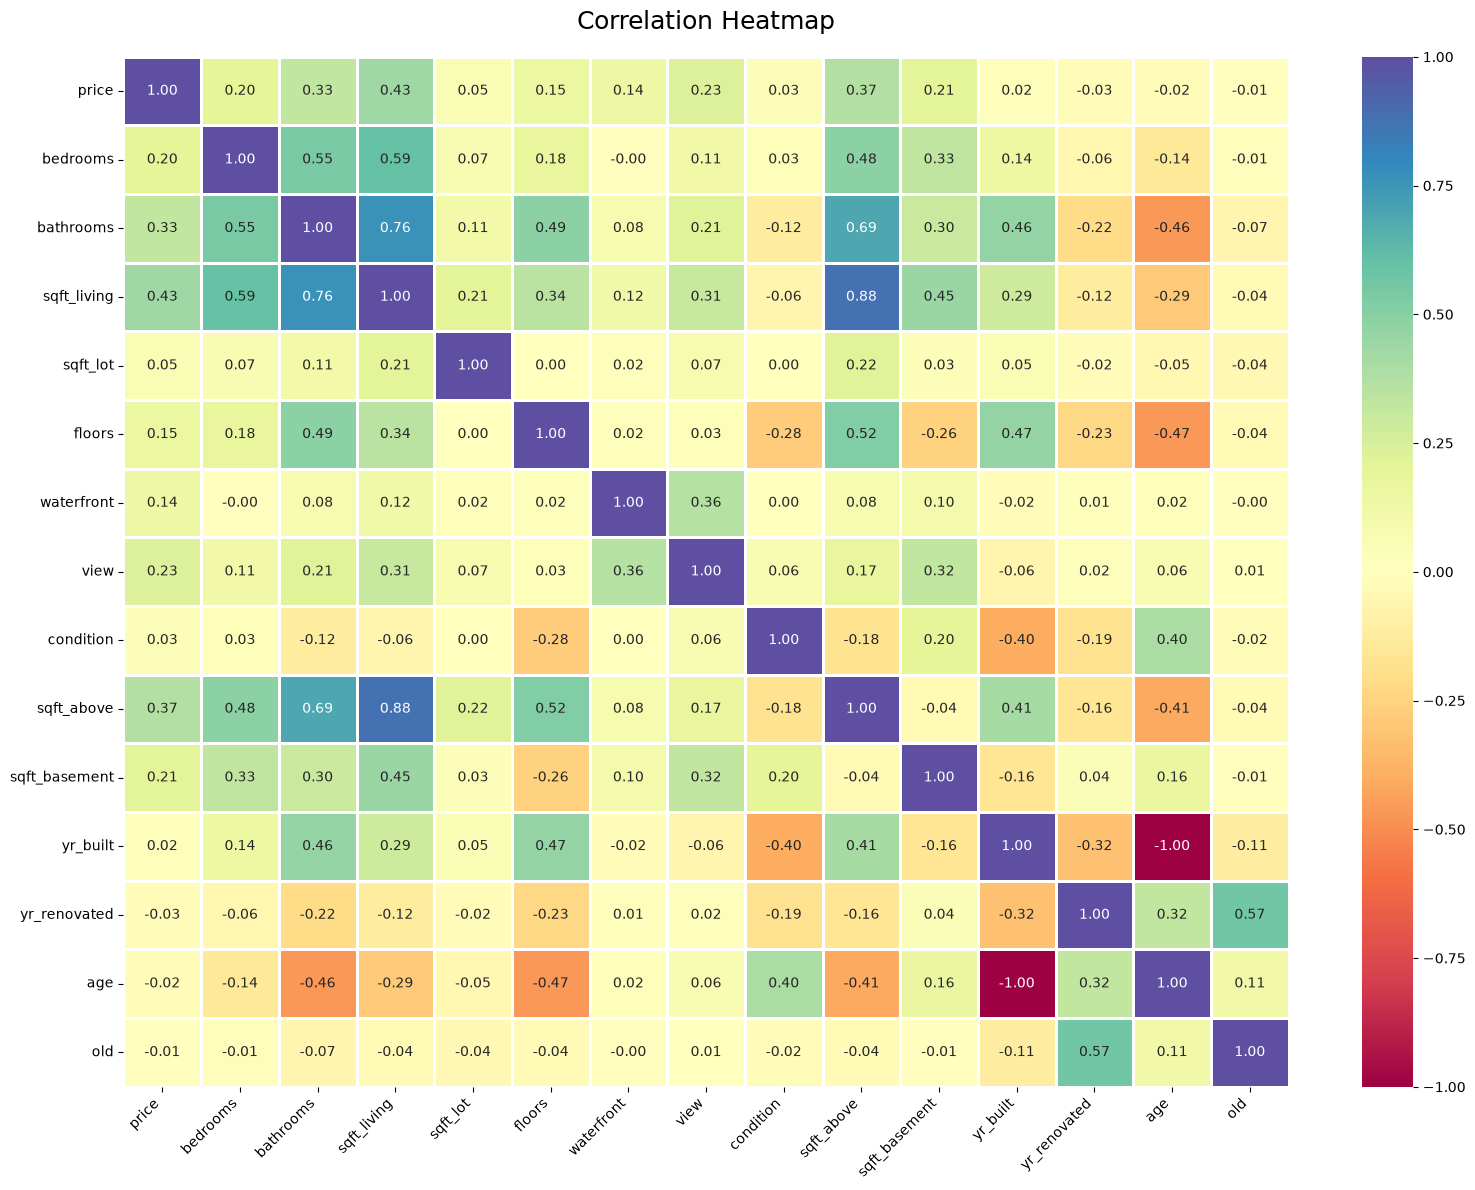

In [51]:
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr,
    annot=True,
    cmap='Spectral',
    fmt='.2f',
    linewidths=0.8,
    linecolor='white',
    annot_kws={'size': 10}
)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title('Correlation Heatmap', fontsize=18, pad=20)
plt.tight_layout()
plt.show()

In [12]:
raw.statezip.unique()

<StringArray>
['WA 98133', 'WA 98119', 'WA 98042', 'WA 98008', 'WA 98052', 'WA 98115',
 'WA 98038', 'WA 98045', 'WA 98155', 'WA 98105', 'WA 98074', 'WA 98106',
 'WA 98007', 'WA 98092', 'WA 98198', 'WA 98006', 'WA 98102', 'WA 98011',
 'WA 98125', 'WA 98003', 'WA 98136', 'WA 98033', 'WA 98029', 'WA 98117',
 'WA 98034', 'WA 98072', 'WA 98023', 'WA 98107', 'WA 98166', 'WA 98116',
 'WA 98024', 'WA 98055', 'WA 98077', 'WA 98027', 'WA 98059', 'WA 98075',
 'WA 98014', 'WA 98065', 'WA 98199', 'WA 98053', 'WA 98058', 'WA 98122',
 'WA 98103', 'WA 98112', 'WA 98005', 'WA 98118', 'WA 98177', 'WA 98004',
 'WA 98019', 'WA 98144', 'WA 98168', 'WA 98001', 'WA 98056', 'WA 98146',
 'WA 98028', 'WA 98148', 'WA 98057', 'WA 98040', 'WA 98010', 'WA 98051',
 'WA 98031', 'WA 98109', 'WA 98030', 'WA 98126', 'WA 98032', 'WA 98178',
 'WA 98288', 'WA 98108', 'WA 98070', 'WA 98188', 'WA 98002', 'WA 98039',
 'WA 98022', 'WA 98068', 'WA 98047', 'WA 98050', 'WA 98354']
Length: 77, dtype: str

In [79]:
raw.city.unique()

<StringArray>
[          'Shoreline',             'Seattle',                'Kent',
            'Bellevue',             'Redmond',        'Maple Valley',
          'North Bend',    'Lake Forest Park',           'Sammamish',
              'Auburn',          'Des Moines',             'Bothell',
         'Federal Way',            'Kirkland',            'Issaquah',
         'Woodinville',       'Normandy Park',           'Fall City',
              'Renton',           'Carnation',          'Snoqualmie',
              'Duvall',              'Burien',           'Covington',
 'Inglewood-Finn Hill',             'Kenmore',           'Newcastle',
       'Mercer Island',       'Black Diamond',          'Ravensdale',
          'Clyde Hill',              'Algona',           'Skykomish',
             'Tukwila',              'Vashon',        'Yarrow Point',
              'SeaTac',              'Medina',            'Enumclaw',
     'Snoqualmie Pass',             'Pacific',  'Beaux Arts Village',
      

In [13]:
temp = cleaned.groupby('statezip')

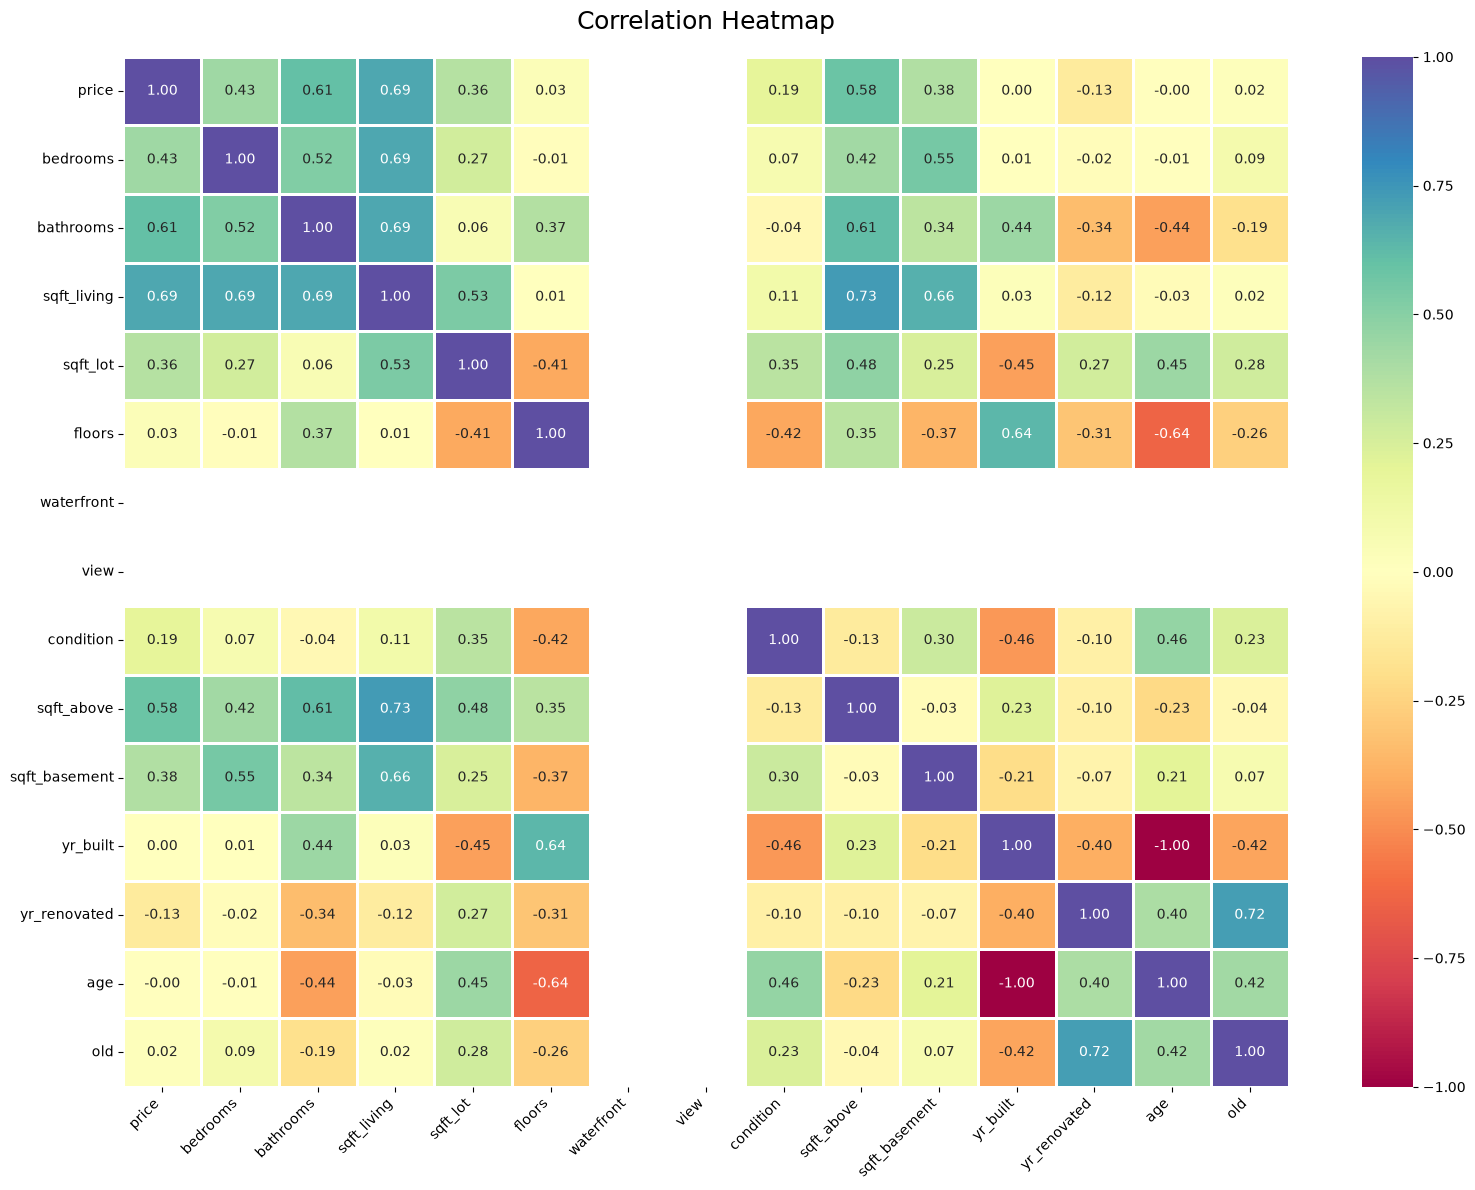

In [52]:
test = temp.get_group('WA 98133')
corr = test[num_col].corr(numeric_only = True)
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr,
    annot=True,
    cmap='Spectral',
    fmt='.2f',
    linewidths=0.8,
    linecolor='white',
    annot_kws={'size': 10}
)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title('Correlation Heatmap', fontsize=18, pad=20)
plt.tight_layout()
plt.show()

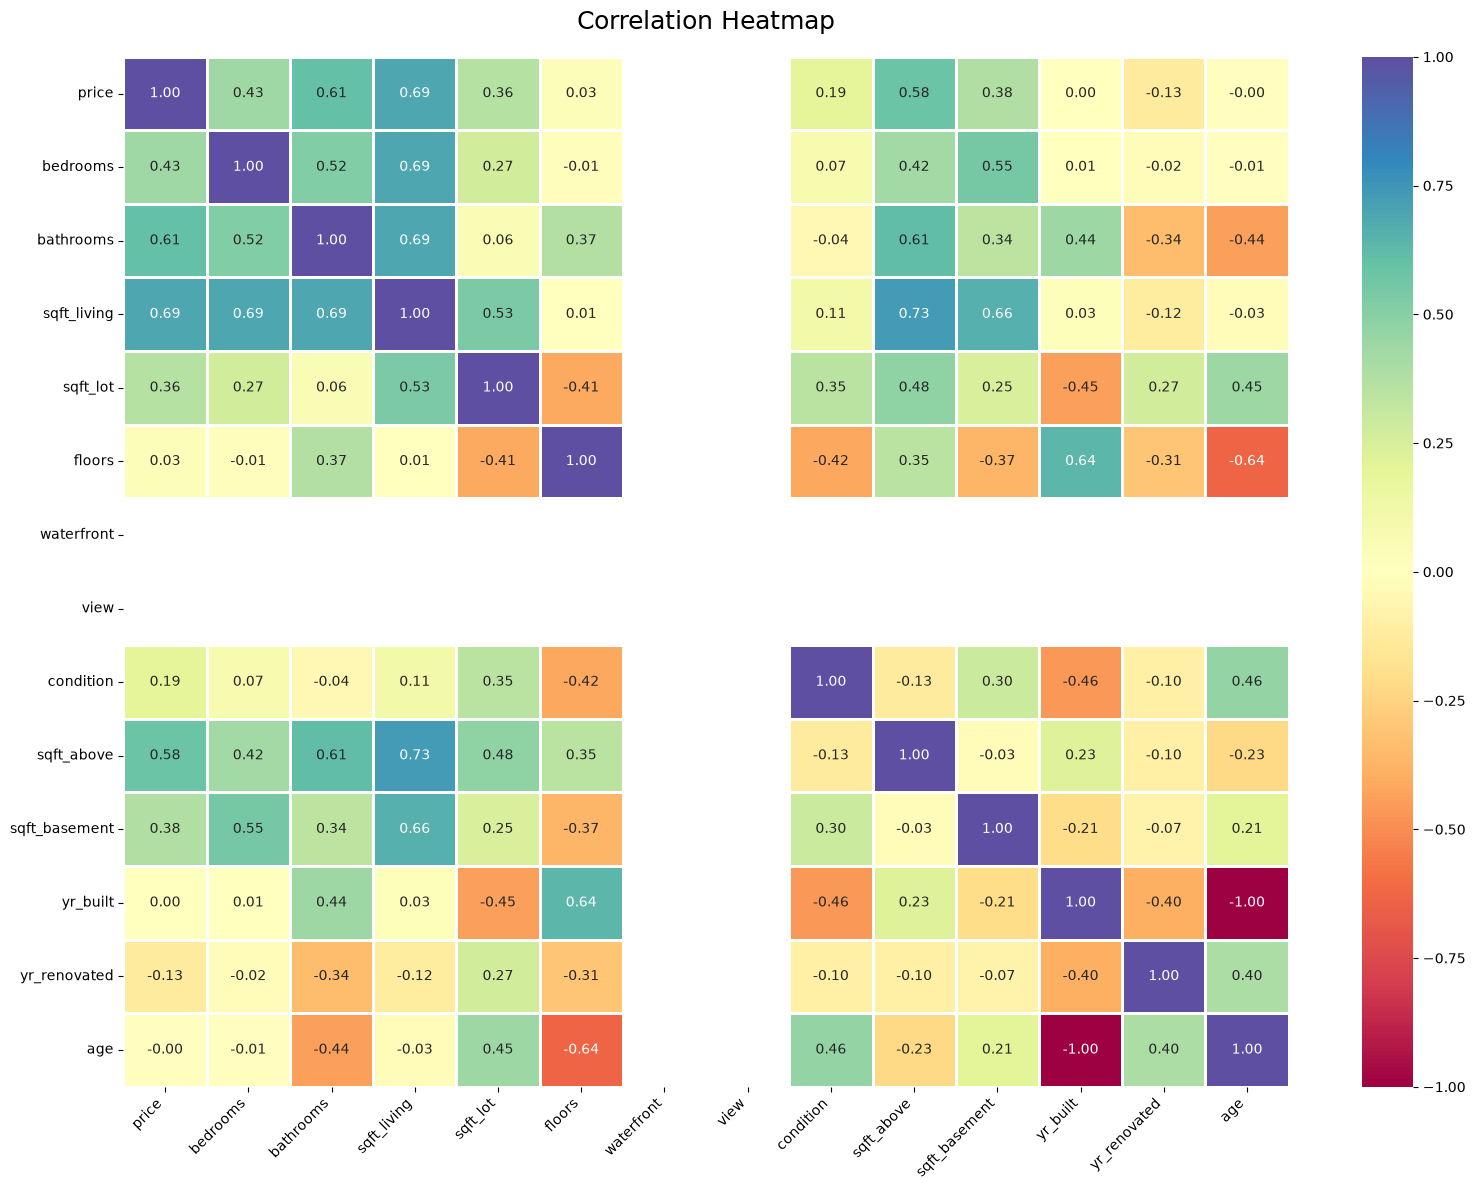

In [15]:
test = temp.get_group('WA 98133')
corr = test[num_col].corr(numeric_only = True)
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr,
    annot=True,
    cmap='Spectral',
    fmt='.2f',
    linewidths=0.8,
    linecolor='white',
    annot_kws={'size': 10}
)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title('Correlation Heatmap', fontsize=18, pad=20)
plt.tight_layout()
plt.show()

In [24]:
len(test)

93

In [17]:
cleaned['statezip'].value_counts().describe()

count     77.00000
mean      59.74026
std       34.84190
min        1.00000
25%       30.00000
50%       59.00000
75%       86.00000
max      148.00000
Name: count, dtype: float64

In [18]:
cleaned['statezip'].value_counts().sort_values()

statezip
WA 98068      1
WA 98354      2
WA 98050      2
WA 98288      3
WA 98047      6
           ... 
WA 98006    110
WA 98115    130
WA 98117    132
WA 98052    135
WA 98103    148
Name: count, Length: 77, dtype: int64

In [74]:
features = [
    'bathrooms',
    'bedrooms',
    'sqft_living',
    'sqft_above',
    'price'
]

corr_by_zip = (
    cleaned
    .groupby('statezip')[features]
    .corr()['price']
)
corr_by_zip = corr_by_zip.unstack()
corr_by_zip.head()

,bathrooms,bedrooms,sqft_living,sqft_above,price
statezip,,,,,
WA 98001,0.453413,0.335424,0.739967,0.644717,1.0
WA 98002,0.380491,0.248004,0.485855,0.653540,1.0
WA 98003,0.702749,0.397376,0.794933,0.772321,1.0
WA 98004,0.534095,0.340803,0.808088,0.723711,1.0
WA 98005,0.505066,0.166778,0.661225,0.725597,1.0


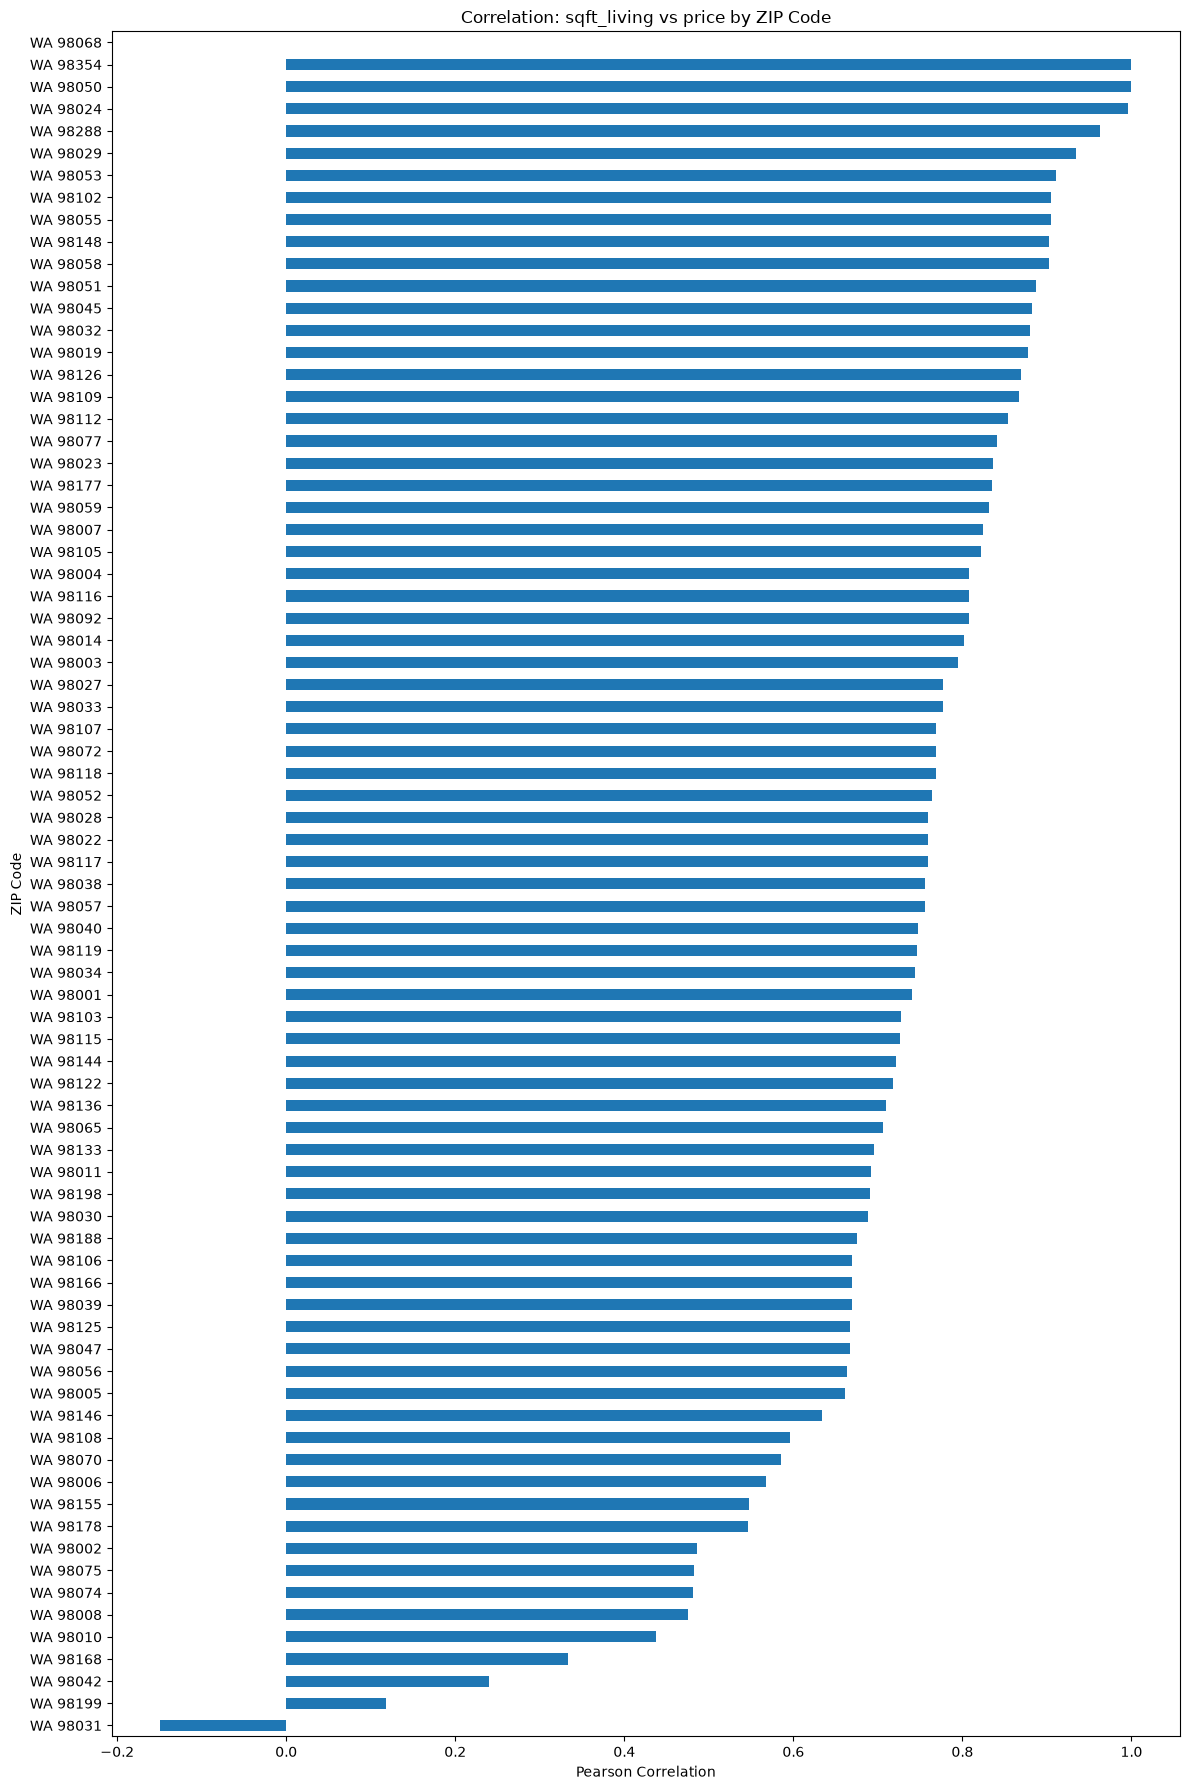

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_by_zip['sqft_living'].sort_values().plot(
    kind='barh',
    figsize=(12, 18)
)

plt.title('Correlation: sqft_living vs price by ZIP Code')
plt.xlabel('Pearson Correlation')
plt.ylabel('ZIP Code')

plt.tight_layout()
plt.show()

In [26]:
cleaned['yr_renovated']

0       2005
1          0
2          0
3          0
4       1992
        ... 
4595    1979
4596    2009
4597       0
4598       0
4599       0
Name: yr_renovated, Length: 4600, dtype: int64

In [27]:
cleaned['old'] = cleaned['date'].dt.year - cleaned['yr_renovated']

C:\Users\aroma\AppData\Local\Temp\ipykernel_16628\3888008483.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  cleaned['old'] = cleaned['date'].dt.year - cleaned['yr_renovated']


In [41]:
cleaned.loc[cleaned['old'] == 2014,'old'] = 0

In [59]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   str    
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   str    
 15  city           4600 non-null   str    
 16  statezip       4600 non-null   str    
 17  country        4600 non-null   str    
dtypes: float64(4), int6

### City

In [76]:
temp = cleaned.groupby('city')[num_col].corr()['price']
test= temp.unstack()
test.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,age,old
city,,,,,,,,,,,,,,,
Algona,1.0,0.934779,0.658436,0.885422,-0.802403,0.672165,NaN,NaN,0.195938,0.885422,NaN,0.695080,-0.595752,-0.695080,-0.595752
Auburn,1.0,0.251522,0.578566,0.814327,0.492788,0.387571,NaN,0.282946,-0.276461,0.811852,0.017208,0.429073,-0.057288,-0.429073,-0.047533
Beaux Arts Village,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Bellevue,1.0,0.208169,0.448918,0.673568,0.284349,0.338388,0.57122,0.296253,-0.139112,0.611633,0.219506,0.254368,-0.073384,-0.254368,-0.002162
Black Diamond,1.0,0.097783,0.580285,0.438050,-0.042787,0.219177,NaN,NaN,-0.209387,0.449224,-0.158655,-0.125224,0.740615,0.125224,0.649567


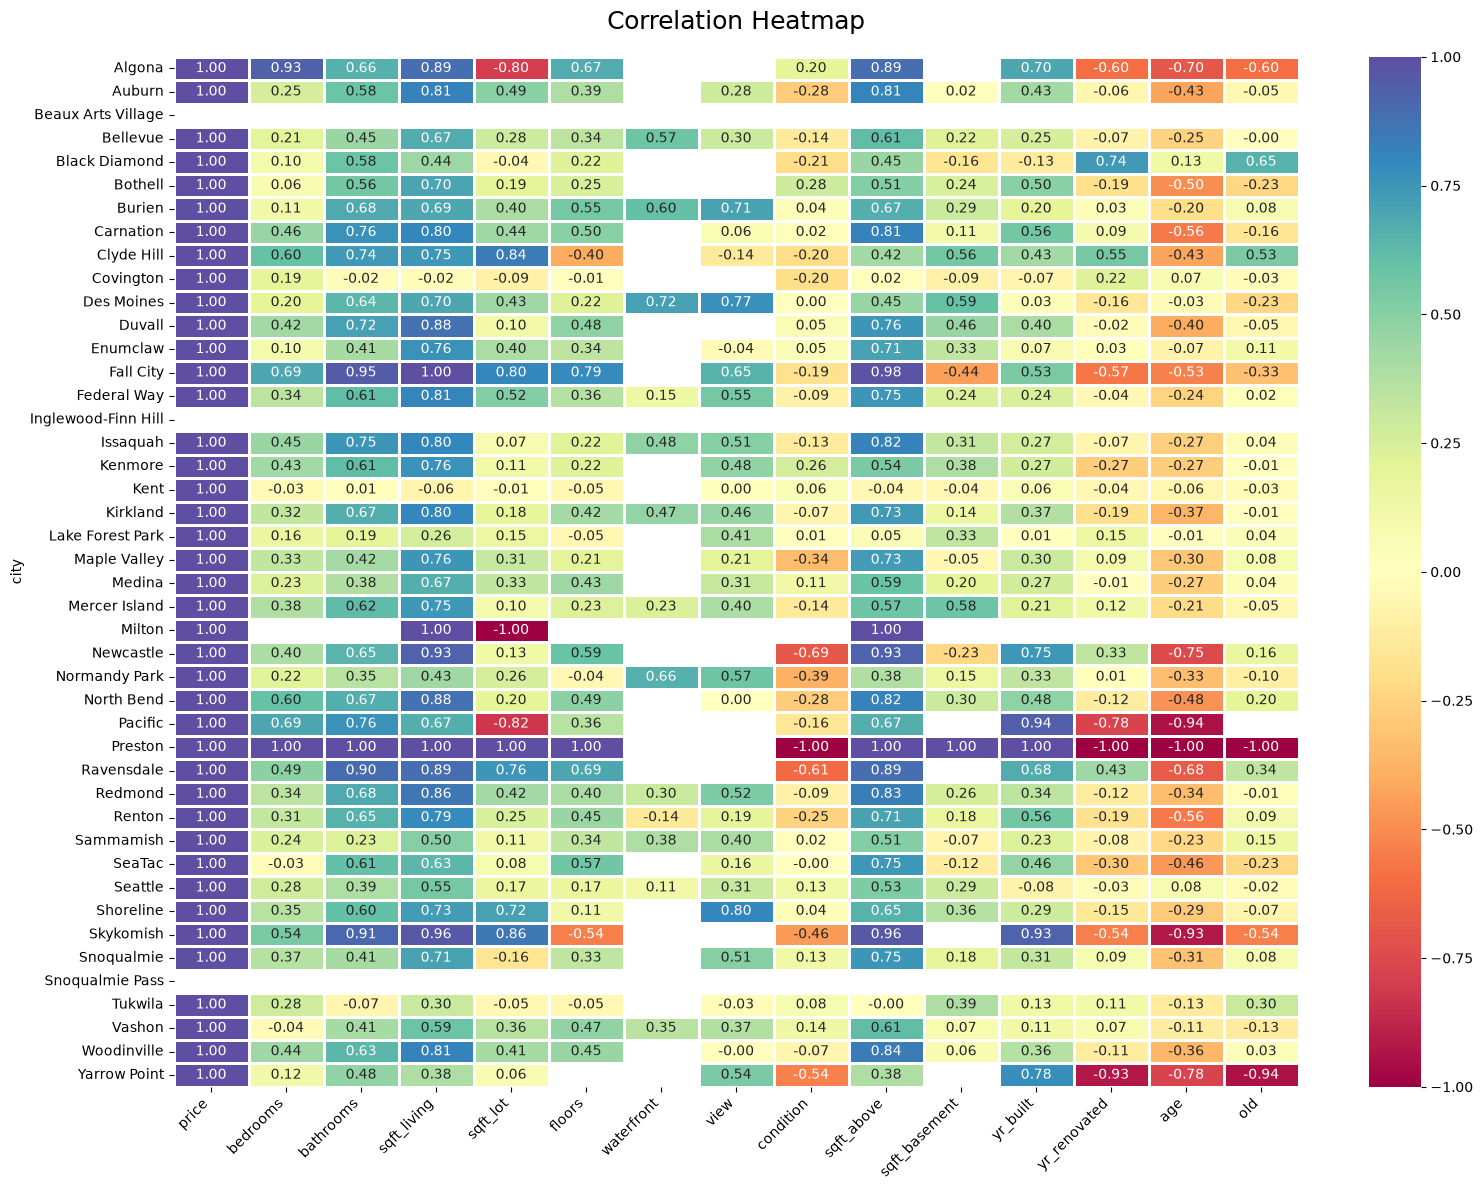

In [78]:

plt.figure(figsize=(16, 12))
sns.heatmap(
    test,
    annot=True,
    cmap='Spectral',
    fmt='.2f',
    linewidths=0.8,
    linecolor='white',
    annot_kws={'size': 10}
)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title('Correlation Heatmap', fontsize=18, pad=20)
plt.tight_layout()
plt.show()

In [66]:
cleaned['city'] = raw['city']

C:\Users\aroma\AppData\Local\Temp\ipykernel_16628\68003495.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  cleaned['city'] = raw['city']


In [80]:
print(cleaned.columns.tolist())

['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'street_freq', 'city_Algona', 'city_Auburn', 'city_Beaux Arts Village', 'city_Bellevue', 'city_Black Diamond', 'city_Bothell', 'city_Burien', 'city_Carnation', 'city_Clyde Hill', 'city_Covington', 'city_Des Moines', 'city_Duvall', 'city_Enumclaw', 'city_Fall City', 'city_Federal Way', 'city_Inglewood-Finn Hill', 'city_Issaquah', 'city_Kenmore', 'city_Kent', 'city_Kirkland', 'city_Lake Forest Park', 'city_Maple Valley', 'city_Medina', 'city_Mercer Island', 'city_Milton', 'city_Newcastle', 'city_Normandy Park', 'city_North Bend', 'city_Pacific', 'city_Preston', 'city_Ravensdale', 'city_Redmond', 'city_Renton', 'city_Sammamish', 'city_SeaTac', 'city_Seattle', 'city_Shoreline', 'city_Skykomish', 'city_Snoqualmie', 'city_Snoqualmie Pass', 'city_Tukwila', 'city_Vashon', 'city_Woodinville', 'city_Yarrow Point', 

In [81]:
y = ['price']
x = ['bedrooms','bathrooms','sqft_living','sqft_above','city_Algona', 'city_Auburn', 
'city_Beaux Arts Village', 'city_Bellevue', 'city_Black Diamond', 'city_Bothell', 
'city_Burien', 'city_Carnation', 'city_Clyde Hill', 'city_Covington', 'city_Des Moines', 
'city_Duvall', 'city_Enumclaw', 'city_Fall City', 'city_Federal Way', 
'city_Inglewood-Finn Hill', 'city_Issaquah', 'city_Kenmore', 'city_Kent', 'city_Kirkland', 
'city_Lake Forest Park', 'city_Maple Valley', 'city_Medina', 'city_Mercer Island', 
'city_Milton', 'city_Newcastle', 'city_Normandy Park', 'city_North Bend', 'city_Pacific', 
'city_Preston', 'city_Ravensdale', 'city_Redmond', 'city_Renton', 'city_Sammamish', 
'city_SeaTac', 'city_Seattle', 'city_Shoreline', 'city_Skykomish', 'city_Snoqualmie', 
'city_Snoqualmie Pass', 'city_Tukwila', 'city_Vashon', 'city_Woodinville', 
'city_Yarrow Point', 'statezip_WA 98001', 'statezip_WA 98002', 'statezip_WA 98003', 
'statezip_WA 98004', 'statezip_WA 98005', 'statezip_WA 98006', 'statezip_WA 98007', 
'statezip_WA 98008', 'statezip_WA 98010', 'statezip_WA 98011', 'statezip_WA 98014', 
'statezip_WA 98019', 'statezip_WA 98022', 'statezip_WA 98023', 'statezip_WA 98024', 
'statezip_WA 98027', 'statezip_WA 98028', 'statezip_WA 98029', 'statezip_WA 98030', 
'statezip_WA 98031', 'statezip_WA 98032', 'statezip_WA 98033', 'statezip_WA 98034', 
'statezip_WA 98038', 'statezip_WA 98039', 'statezip_WA 98040', 'statezip_WA 98042', 
'statezip_WA 98045', 'statezip_WA 98047', 'statezip_WA 98050', 'statezip_WA 98051', 
'statezip_WA 98052', 'statezip_WA 98053', 'statezip_WA 98055', 'statezip_WA 98056', 
'statezip_WA 98057', 'statezip_WA 98058', 'statezip_WA 98059', 'statezip_WA 98065', 
'statezip_WA 98068', 'statezip_WA 98070', 'statezip_WA 98072', 'statezip_WA 98074', 
'statezip_WA 98075', 'statezip_WA 98077', 'statezip_WA 98092', 'statezip_WA 98102', 
'statezip_WA 98103', 'statezip_WA 98105', 'statezip_WA 98106', 'statezip_WA 98107', 
'statezip_WA 98108', 'statezip_WA 98109', 'statezip_WA 98112', 'statezip_WA 98115', 
'statezip_WA 98116', 'statezip_WA 98117', 'statezip_WA 98118', 'statezip_WA 98119', 
'statezip_WA 98122', 'statezip_WA 98125', 'statezip_WA 98126', 'statezip_WA 98133', 
'statezip_WA 98136', 'statezip_WA 98144', 'statezip_WA 98146', 'statezip_WA 98148', 
'statezip_WA 98155', 'statezip_WA 98166', 'statezip_WA 98168', 'statezip_WA 98177', 
'statezip_WA 98178', 'statezip_WA 98188',
'statezip_WA 98198', 'statezip_WA 98199', 'statezip_WA 98288', 'statezip_WA 98354']

In [83]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(
    cleaned[x],
    cleaned[y],
    test_size = 0.2,
    random_state = 42
)